In [1]:
# save pdf figures so that text is editable in AI
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

### Load in cell-by-gene matrix

In [2]:
import pandas as pd
import numpy as np

# load cell-by-gene matrix
all_cbg_rep1 = pd.read_csv('/home/zgibbs/STARR-FISH/cell_by_CRE_10_12_2023.csv')
all_cbg_rep2 = pd.read_csv('/home/zgibbs/STARR-FISH/cell_by_CRE_10_12_2023_rep.csv')

In [3]:
all_cbg_rep1.columns[1:21]

Index(['CRE001', 'CRE002', 'CRE003', 'CRE004', 'CRE005', 'CRE006', 'CRE007',
       'CRE008', 'CRE009', 'CRE010', 'CRE011', 'CRE012', 'CRE013', 'CRE014',
       'CRE015', 'CRE016', 'CRE017', 'CRE018', 'CRE019', 'CRE020'],
      dtype='object')

In [8]:
cre_presence = []

for cre in all_cbg_rep1.columns[1:21]:
    present = all_cbg_rep1[cre] > 0
    present_ = present.sum()
    present__ = present_/len(all_cbg_rep1)
    cre_presence.append(present__)

cre_presence.insert(0, 'percent detected')
cre_names = [cre for cre in all_cbg_rep1.columns[:21]]
cbg = all_cbg_rep1.filter(cre_names, axis=1)
cbg.loc[cbg.index.max() + 1, :] = cre_presence

In [ ]:
# import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots()
ax = sns.histplot(x=cbg.iloc[-1,1:21], binwidth=0.05, binrange=(0,1), legend=False, kde=True)
ax.set_xlim(0,1)
ax.set_xlabel('Fraction of cells with detected transcripts')
ax.set_ylabel('No. of CRE-barcodes')
# plt.savefig('/home/zgibbs/STARR-FISH/HCT116_20CRE_analysis/figures/fraction_of_cells_transcript_detected_histplot_240505', dpi=450)

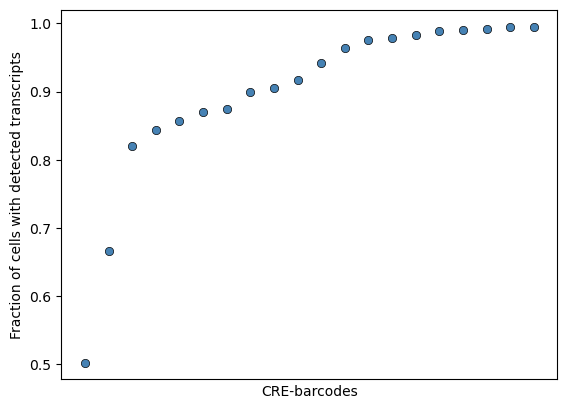

In [25]:
fig, ax = plt.subplots()
ax = sns.scatterplot(x=range(0,20),y=np.sort(cbg.iloc[-1,1:21]), facecolor='steelblue', edgecolor='k', lw=0.2)
ax.set_xlim(-1,20)
ax.set_xlabel('CRE-barcodes')
ax.set_ylabel('Fraction of cells with detected transcripts')
plt.xticks([])
# plt.savefig('/home/zgibbs/STARR-FISH/HCT116_20CRE_analysis/figures/fraction_of_cells_transcript_detected_scatterplot_240504', dpi=450)

In [245]:
cbg_means = pd.DataFrame(list(zip(all_cbg_rep1.columns[1:286], all_cbg_rep1.mean(axis=0)[:20])), columns = ['id', 'score'])
cbg_means2 = pd.DataFrame(list(zip(all_cbg_rep2.columns[1:286], all_cbg_rep2.mean(axis=0)[:20])), columns = ['id', 'score'])

/tmp/ipykernel_1168543/3540562227.py:1: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  cbg_means = pd.DataFrame(list(zip(all_cbg_rep1.columns[1:286], all_cbg_rep1.mean(axis=0)[:285])), columns = ['id', 'score'])
/tmp/ipykernel_1168543/3540562227.py:2: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  cbg_means2 = pd.DataFrame(list(zip(all_cbg_rep2.columns[1:286], all_cbg_rep2.mean(axis=0)[:285])), columns = ['id', 'score'])


### Linear regression analysis of data (un-normalized)

In [137]:
all_cbg_rep1['blanks'] = all_cbg_rep1.loc[:, 'blank0000':'blank0166'].mean(axis=1)
all_cbg_rep2['blanks'] = all_cbg_rep2.loc[:, 'blank0000':'blank0166'].mean(axis=1)

In [4]:
all_cbg_rep1['total transcripts'] = all_cbg_rep1.iloc[:,1:21].sum(axis=1)
all_cbg_rep2['total transcripts'] = all_cbg_rep2.iloc[:,1:21].sum(axis=1)

In [5]:
from scipy import stats

res_total = []

for cre in all_cbg_rep1.columns[1:453]:
    res = stats.linregress(all_cbg_rep1['total transcripts'], all_cbg_rep1[cre])
    res_total.append(res)

In [6]:
from scipy import stats

res_total2 = []

for cre in all_cbg_rep2.columns[1:453]:
    res = stats.linregress(all_cbg_rep2['total transcripts'], all_cbg_rep2[cre])
    res_total2.append(res)

In [7]:
y = [res_total[i].slope for i in range(20)]
y2 = [res_total2[i].slope for i in range(20)]

In [8]:
yerr = [res_total[i].stderr*1.96 for i in range(20)]
yerr2 = [res_total2[i].stderr*1.96 for i in range(20)]

In [9]:
d_full = pd.DataFrame(list(zip(all_cbg_rep1.columns[1:21], y, yerr)), columns = ['id', 'score', 'stderr'])
d_full2 = pd.DataFrame(list(zip(all_cbg_rep2.columns[1:21], y2, yerr2)), columns = ['id', 'score', 'stderr'])

In [10]:
d_full_sorted = d_full.sort_values('score', axis=0, ascending=False)
d_full_sorted2 = d_full2.sort_values('score', axis=0, ascending=False)

In [11]:
d_full_sorted

,id,score,stderr
1,CRE002,0.104789,0.000917
17,CRE018,0.092295,0.000405
19,CRE020,0.088979,0.000383
0,CRE001,0.088754,0.000700
2,CRE003,0.079166,0.001232
4,CRE005,0.077372,0.000416
7,CRE008,0.075421,0.000457
12,CRE013,0.075049,0.000328
3,CRE004,0.073501,0.000524
6,CRE007,0.067230,0.000316


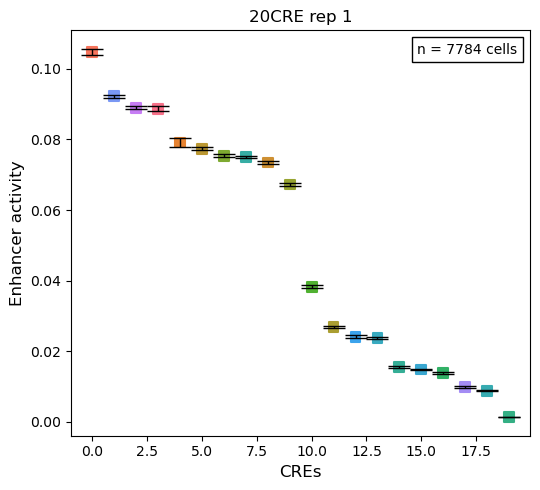

In [25]:
# Plot the enhancer activity scores in a descending order

import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText

fig, ax = plt.subplots(figsize=(5.5,5))

ax.scatter(range(0,20), d_full_sorted['score'], marker='s', c=[colors[i] for i in d_full_sorted['id']], s=50, lw=1.5)
ax.errorbar(range(0,20), d_full_sorted['score'], d_full_sorted['stderr'], linestyle='', linewidth=1, capsize=8, mew=1, ecolor='k')
plt.xticks(None)
ax.set_ylabel('Enhancer activity', fontsize=12)
ax.set_title('20CRE rep 1')
ax.set_xlabel('CREs', fontsize=12)

numcells = len(all_cbg_rep1)

anchored_text = AnchoredText(f"n = {numcells} cells", loc=1)
ax.add_artist(anchored_text)

plt.tight_layout()
# plt.savefig('/home/zgibbs/STARR-FISH/HCT116_20CRE_analysis/figures/rep1_activity_240607.pdf')
plt.show()

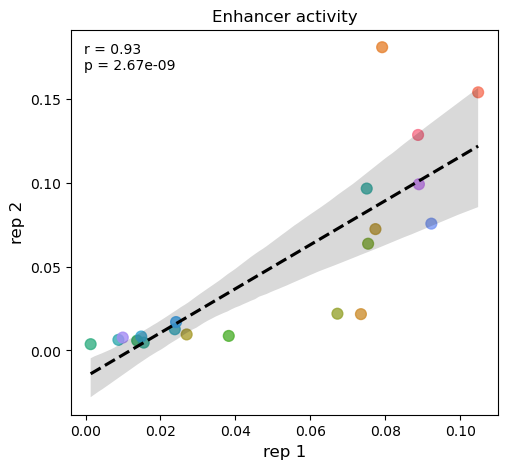

In [65]:
# plot the correlation between replicates

import seaborn as sns
from scipy import stats

fig, ax = plt.subplots(figsize=(5.5,5))

x = d_full['score']
y = d_full2['score']

# sns.set_palette("viridis")

sns.regplot(x=x, y=y,
            scatter_kws={'color' : [colors[i] for i in d_full['id']], 's' : 60},
            line_kws={'ls' : 'dashed', 'color' : 'k'})

ax.set_ylabel('rep 2', fontsize=12)
ax.set_xlabel('rep 1', fontsize=12)
ax.set_title('Enhancer activity')

stats = stats.spearmanr(x, y)

corrcoef = np.around(stats[0], 2)
pval = np.format_float_scientific(stats[1], 2)

anchored_text = AnchoredText(f"r = {corrcoef}\np = {pval}", loc=2, frameon=False)
ax.add_artist(anchored_text)

# plt.savefig('/home/zgibbs/STARR-FISH/HCT116_20CRE_analysis/figures/rep1_vs_rep2_activity_240607.pdf')
plt.show()

### Correlate STARR-FISH with bulk RNA-seq counts

In [57]:
# Load in featureCounts table from bulk RNA-seq sample
RNAseq = pd.read_csv('/home/zgibbs/STARR-FISH/RNA-seq/HCT116_CRE20_rep1/CRE20_featureCounts_output.txt', sep = '\t', header=1)
RNAseq2 = pd.read_csv('/home/zgibbs/STARR-FISH/RNA-seq/HCT116_CRE20_rep2/CRE20_featureCounts_output.txt', sep = '\t', header=1)

# Change name of last column
RNAseq = RNAseq.rename(columns={'/projects/ps-renlab2/zgibbs/STARR-FISH/RNAseq/dedup.aligned_reads_CRE20_rep1.bam': 'Counts'})
RNAseq2 = RNAseq2.rename(columns={'/projects/ps-renlab2/zgibbs/STARR-FISH/RNAseq/CRE20_rep2/dedup.aligned_reads_CRE20_rep2.bam': 'Counts'})

# Make a new column for calculated cpm of each CRE transcript
# use the total number of reads from bulk RNA-seq sample here
RNAseq['cpm'] = (RNAseq['Counts'].div(23367352))*1000000 
RNAseq2['cpm'] = (RNAseq2['Counts'].div(69137386))*1000000 

In [58]:
merged = pd.merge(d_full, RNAseq,how='left', left_on='id', right_on='Geneid')
merged2 = pd.merge(d_full2, RNAseq2,how='left', left_on='id', right_on='Geneid')

In [59]:
merged

,id,score,stderr,Geneid,Chr,Start,End,Strand,Length,Counts,cpm
0,CRE001,0.088754,0.000700,CRE001,CRE001;CRE001,1;192,191;573,+;+,573,25692,1099.482731
1,CRE002,0.104789,0.000917,CRE002,CRE002;CRE002,1;192,191;573,+;+,573,21656,926.763118
2,CRE003,0.079166,0.001232,CRE003,CRE003;CRE003,1;192,191;573,+;+,573,40167,1718.936746
3,CRE004,0.073501,0.000524,CRE004,CRE004;CRE004,1;192,191;573,+;+,573,3679,157.441887
4,CRE005,0.077372,0.000416,CRE005,CRE005;CRE005,1;192,191;573,+;+,573,6460,276.454089
5,CRE006,0.026992,0.000312,CRE006,CRE006;CRE006,1;192,191;573,+;+,573,584,24.992134
6,CRE007,0.067230,0.000316,CRE007,CRE007;CRE007,1;192,191;573,+;+,573,4903,209.822662
7,CRE008,0.075421,0.000457,CRE008,CRE008;CRE008,1;192,191;573,+;+,573,4408,188.639260
8,CRE009,0.038228,0.000418,CRE009,CRE009;CRE009,1;192,191;573,+;+,573,958,40.997371
9,CRE010,0.013776,0.000235,CRE010,CRE010;CRE010,1;192,191;573,+;+,573,311,13.309167


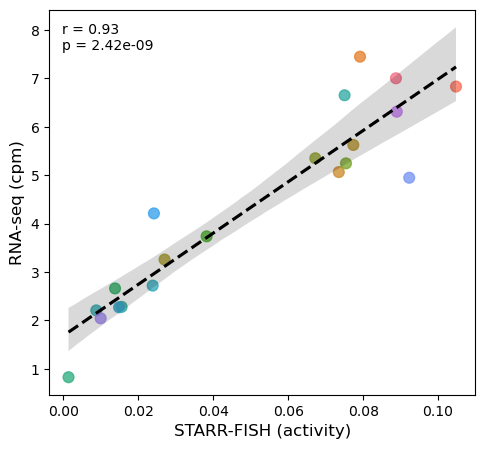

In [63]:
# plot the correlation between replicates

import seaborn as sns
from scipy import stats

fig, ax = plt.subplots(figsize=(5.5,5))

x = merged.score
y = np.log(merged.cpm+1)

# sns.set_palette("viridis")

sns.regplot(x=x, y=y,
            scatter_kws={'color' : [colors[i] for i in d_full['id']], 's' : 60},
            line_kws={'ls' : 'dashed', 'color' : 'k'})

ax.set_ylabel('RNA-seq (cpm)', fontsize=12)
ax.set_xlabel('STARR-FISH (activity)', fontsize=12)
# ax.set_title('Bulk RNA-seq (cpm)')

stats = stats.pearsonr(x, y)

corrcoef = np.around(stats[0], 2)
pval = np.format_float_scientific(stats[1], 2)

anchored_text = AnchoredText(f"r = {corrcoef}\np = {pval}", loc=2, frameon=False)
ax.add_artist(anchored_text)

# plt.savefig('/home/zgibbs/STARR-FISH/HCT116_20CRE_analysis/figures/rep1_activity_vs_RNAseq_240607.pdf')
plt.show()

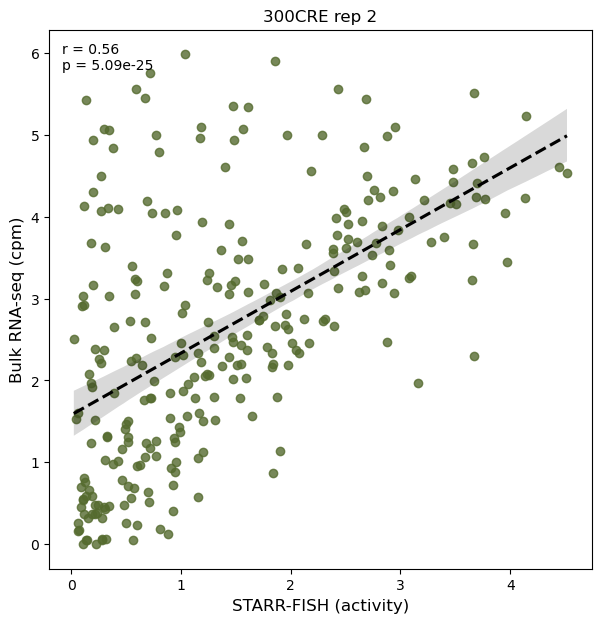

In [271]:
from matplotlib.offsetbox import AnchoredText
from scipy import stats
import seaborn as sns

fig, ax = plt.subplots(figsize=(7,7))

x = np.log(cbg_means2.score+1)
y = np.log(merged2.cpm+1)

sns.regplot(x=x, y=y,
            color='darkolivegreen',
            line_kws={'ls' : 'dashed', 'color' : 'k'})

ax.set_ylabel('Bulk RNA-seq (cpm)', fontsize=12)
ax.set_xlabel('STARR-FISH (activity)', fontsize=12)
ax.set_title('300CRE rep 2')

stats = stats.spearmanr(x, y)

corrcoef = np.around(stats[0], 2)
pval = np.format_float_scientific(stats[1], 2)

anchored_text = AnchoredText(f"r = {corrcoef}\np = {pval}", loc=2, frameon=False)
ax.add_artist(anchored_text)

# plt.savefig('/tscc/projects/ps-renlab2/zgibbs/STARR-FISH/300CRE_HCT116_analysis/figures/rep2_RNAseq_vs_mean_counts_log_spearman', dpi=450)
plt.show()

### Correlate CRE counts vs total transcripts (or among each other)

/tmp/ipykernel_1168543/2644406962.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


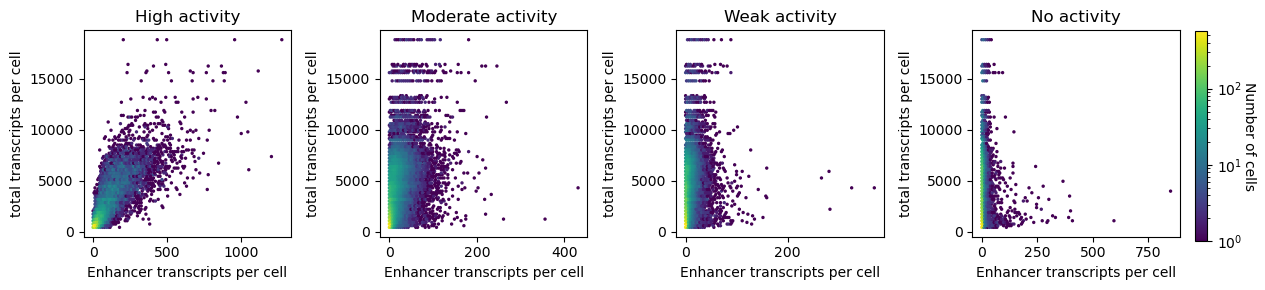

In [64]:
# Plot some examples of the linear regression (fit line)

import matplotlib.pyplot as plt
from scipy import stats

fig, axs = plt.subplots(1, 4, figsize=(12,3))

high = axs[0].hexbin([all_cbg_rep1[i] for i in d_full_sorted['id'][:5]], all_cbg_rep1['total transcripts'], mincnt=1, bins='log')
# cbar1 = plt.colorbar(high, ax=axs[0])
# cbar1.set_label('n cells', rotation=270, labelpad=10)
axs[0].set_ylabel('total transcripts per cell')
axs[0].set_xlabel('Enhancer transcripts per cell')
axs[0].set_title('High activity')

axs[1].hexbin([all_cbg_rep1[i] for i in d_full_sorted['id'][50:100]], all_cbg_rep1['total transcripts'], mincnt=1, bins='log')
# cbar2 = plt.colorbar(moderate, ax=axs[1])
# cbar2.set_label('n cells', rotation=270, labelpad=10)
axs[1].set_ylabel('total transcripts per cell')
axs[1].set_xlabel('Enhancer transcripts per cell')
axs[1].set_title('Moderate activity')

axs[2].hexbin([all_cbg_rep1[i] for i in d_full_sorted['id'][100:150]], all_cbg_rep1['total transcripts'], mincnt=1, bins='log')
# cbar3 = plt.colorbar(weak, ax=axs[2])
# cbar3.set_label('n cells', rotation=270, labelpad=10)
axs[2].set_ylabel('total transcripts per cell')
axs[2].set_xlabel('Enhancer transcripts per cell')
axs[2].set_title('Weak activity')

axs[3].hexbin([all_cbg_rep1[i] for i in d_full_sorted['id'][150:200]], all_cbg_rep1['total transcripts'], mincnt=1, bins='log')
# cbar4 = plt.colorbar(no_act, ax=axs[3])
# cbar4.set_label('n cells', rotation=270, labelpad=10)
axs[3].set_ylabel('total transcripts per cell')
axs[3].set_xlabel('Enhancer transcripts per cell')
axs[3].set_title('No activity')

fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([1, 0.18, 0.01, 0.7])
cbar = fig.colorbar(high, cax=cbar_ax)

# cbar = fig.colorbar(high)
cbar.set_label('Number of cells', rotation=270, labelpad=10)





# x, y = [all_cbg_clean[i] for i in all_cbg_clean.columns], all_cbg_clean['total transcripts']
# # plt.plot(all_cbg_clean['CRE001'], all_cbg_clean['CRE002'], 'o', label='original data')
# # im = plt.hexbin(x, y, mincnt=1, bins='log')
# cbar = plt.colorbar()
# cbar.set_label('n cells',
#                        rotation=270,
#                        labelpad=10)

# stats = stats.pearsonr(x, y)

# corrcoef = np.around(stats[0], 2)
# pval = np.format_float_scientific(stats[1], 2)

# anchored_text = AnchoredText(f"r = {corrcoef}\np = {pval}", loc=2, frameon=False)
# ax.add_artist(anchored_text)

# plt.plot(all_cbg_clean['CRE001'], res001.intercept + res001.slope*all_cbg_clean['CRE001'], 'r', label='fitted line')
# plt.plot(all_cbg['CRE007'], res007.intercept + res007.slope*all_cbg['CRE007'], 'r', label='fitted line')
# plt.plot(all_cbg['CRE012'], res012.intercept + res012.slope*all_cbg['CRE012'], 'g', label='fitted line')
# plt.legend()

plt.tight_layout()
# plt.savefig('/tscc/projects/ps-renlab2/zgibbs/STARR-FISH/10_12_2023__dCRE-20_RNASEQ/figures/CRE_vs_total_transcripts_corr_240228.pdf', bbox_inches='tight')
plt.show()

In [19]:
all_cbg_clean.iloc[:,1:21]

,CRE001,CRE002,CRE003,CRE004,CRE005,CRE006,CRE007,CRE008,CRE009,CRE010,CRE011,CRE012,CRE013,CRE014,CRE015,CRE016,CRE017,CRE018,CRE019,CRE020
0,6,13,12,3,4,0,3,1,1,3,0,1,5,0,2,3,0,8,3,6
1,37,51,31,10,7,9,9,11,8,8,1,4,12,1,5,8,1,12,8,9
2,9,10,8,6,4,7,10,5,6,7,2,3,7,1,4,6,1,5,6,8
3,19,21,29,1,1,0,1,0,0,0,0,0,6,0,0,0,0,4,0,3
4,3,1,2,2,1,2,0,0,0,1,1,1,1,1,1,0,1,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7779,504,610,448,423,285,155,291,259,116,54,4,67,299,10,73,27,25,430,58,348
7780,286,332,331,226,246,140,211,238,157,62,4,47,204,11,70,63,30,313,74,300
7781,307,373,259,211,204,100,177,158,105,48,2,54,233,6,95,29,34,279,18,271
7782,152,117,76,90,115,82,126,129,110,17,5,49,124,17,48,20,41,132,17,141


/tmp/ipykernel_2382258/317743179.py:136: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


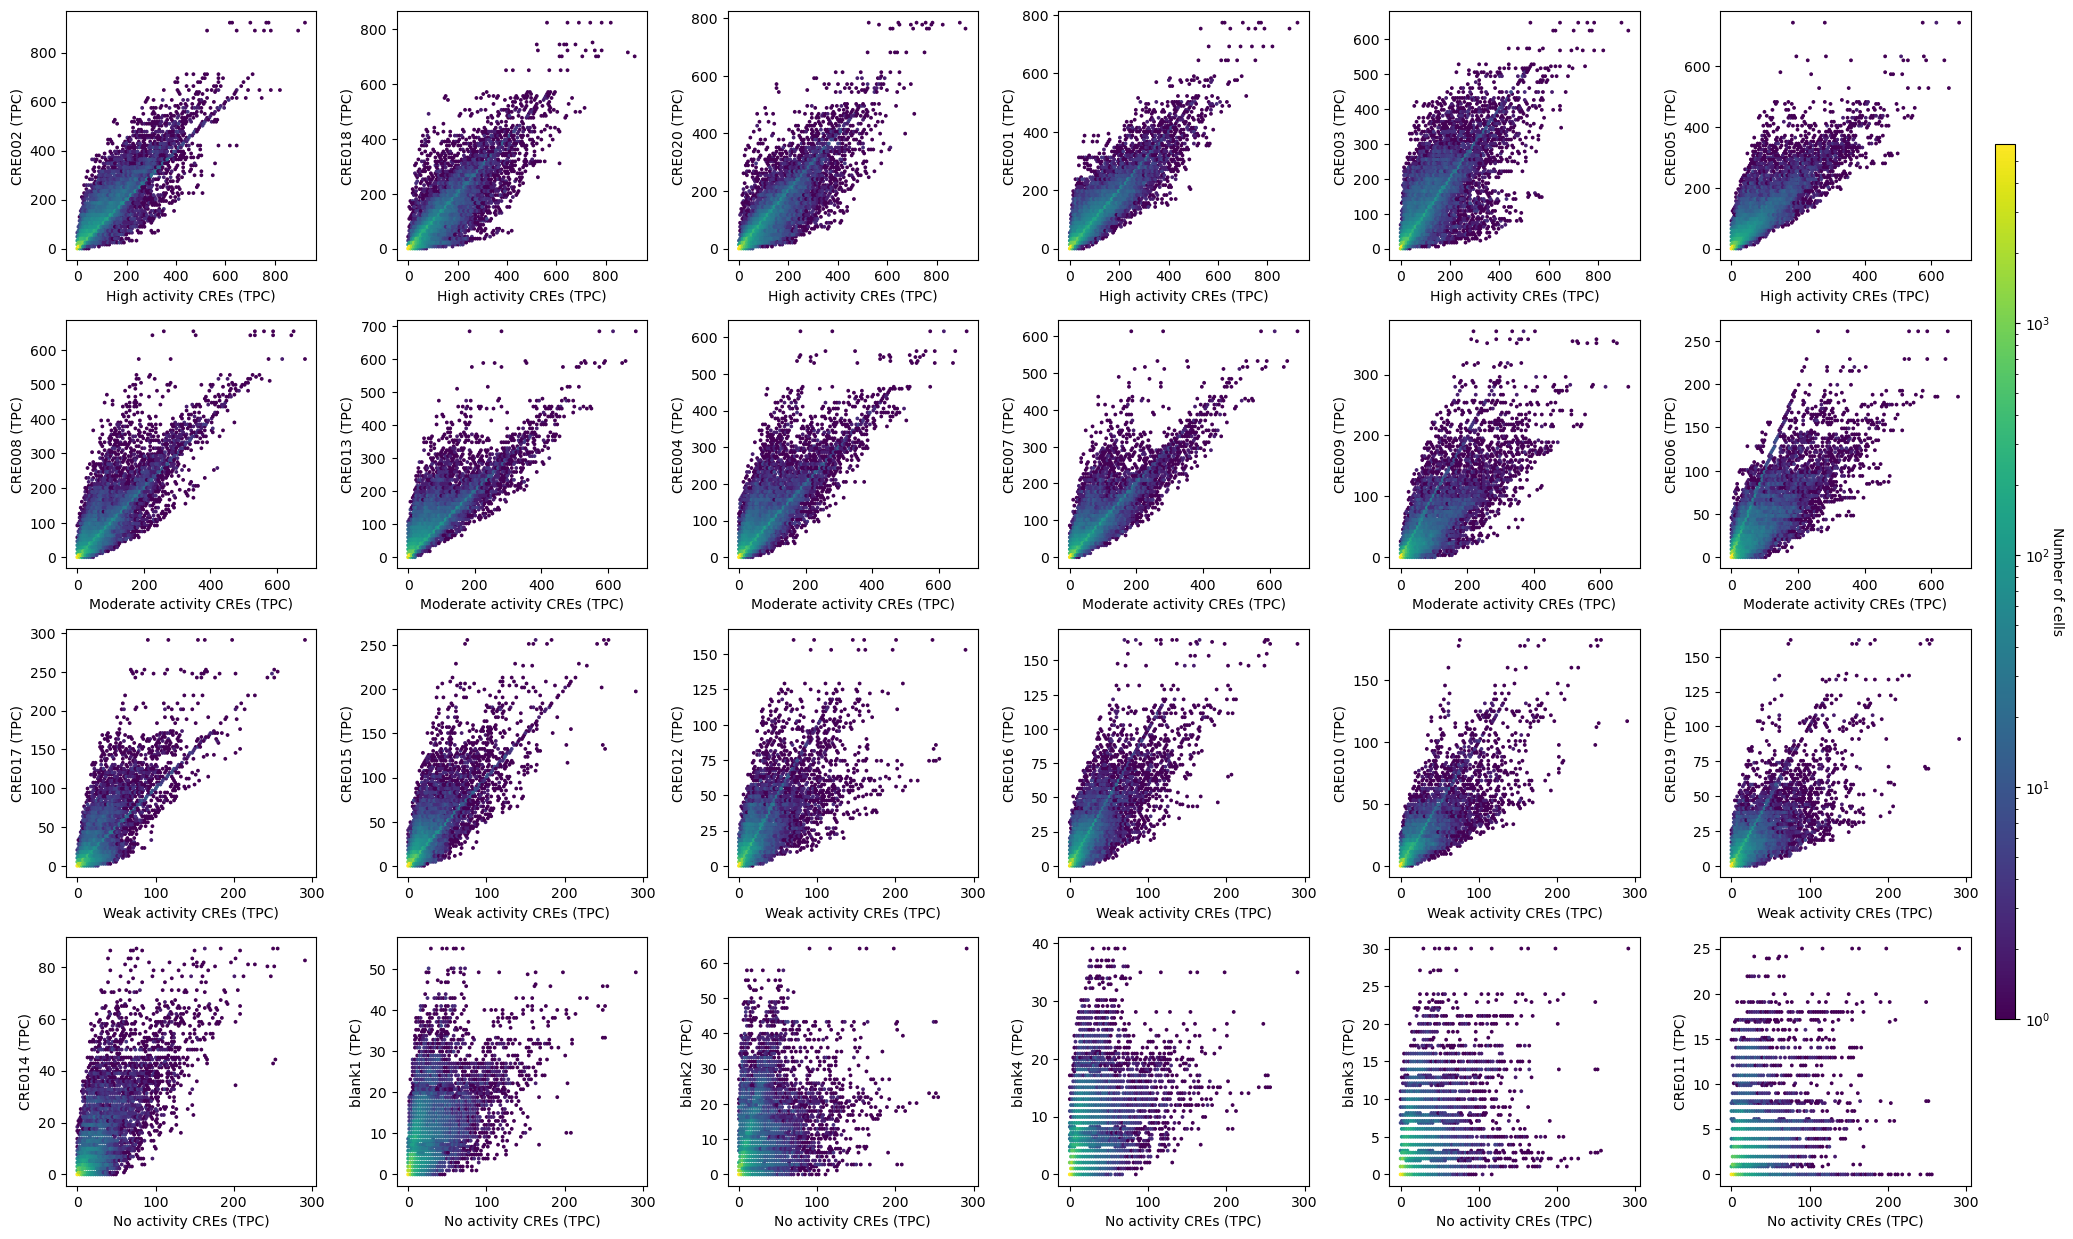

In [16]:
# Plot some examples of the linear regression (fit line)

import matplotlib.pyplot as plt
from scipy import stats

fig, axs = plt.subplots(4, 6, figsize=(20,12.5))

CRE002 = axs[0,0].hexbin([all_cbg_clean[i] for i in d_full_sorted['id'][:6]], all_cbg_clean['CRE002'], mincnt=1, bins='log')
axs[0,0].set_ylabel('CRE002 (TPC)')
axs[0,0].set_xlabel('High activity CREs (TPC)')

axs[0,1].hexbin([all_cbg_clean[i] for i in d_full_sorted['id'][:6]], all_cbg_clean['CRE018'], mincnt=1, bins='log')
axs[0,1].set_ylabel('CRE018 (TPC)')
axs[0,1].set_xlabel('High activity CREs (TPC)')

axs[0,2].hexbin([all_cbg_clean[i] for i in d_full_sorted['id'][:6]], all_cbg_clean['CRE020'], mincnt=1, bins='log')
axs[0,2].set_ylabel('CRE020 (TPC)')
axs[0,2].set_xlabel('High activity CREs (TPC)')

axs[0,3].hexbin([all_cbg_clean[i] for i in d_full_sorted['id'][:6]], all_cbg_clean['CRE001'], mincnt=1, bins='log')
axs[0,3].set_ylabel('CRE001 (TPC)')
axs[0,3].set_xlabel('High activity CREs (TPC)')

axs[0,4].hexbin([all_cbg_clean[i] for i in d_full_sorted['id'][:6]], all_cbg_clean['CRE003'], mincnt=1, bins='log')
axs[0,4].set_ylabel('CRE003 (TPC)')
axs[0,4].set_xlabel('High activity CREs (TPC)')

axs[0,5].hexbin([all_cbg_clean[i] for i in d_full_sorted['id'][6:12]], all_cbg_clean['CRE005'], mincnt=1, bins='log')
axs[0,5].set_ylabel('CRE005 (TPC)')
axs[0,5].set_xlabel('High activity CREs (TPC)')

axs[1,0].hexbin([all_cbg_clean[i] for i in d_full_sorted['id'][6:12]], all_cbg_clean['CRE008'], mincnt=1, bins='log')
axs[1,0].set_ylabel('CRE008 (TPC)')
axs[1,0].set_xlabel('Moderate activity CREs (TPC)')

axs[1,1].hexbin([all_cbg_clean[i] for i in d_full_sorted['id'][6:12]], all_cbg_clean['CRE013'], mincnt=1, bins='log')
axs[1,1].set_ylabel('CRE013 (TPC)')
axs[1,1].set_xlabel('Moderate activity CREs (TPC)')

axs[1,2].hexbin([all_cbg_clean[i] for i in d_full_sorted['id'][6:12]], all_cbg_clean['CRE004'], mincnt=1, bins='log')
axs[1,2].set_ylabel('CRE004 (TPC)')
axs[1,2].set_xlabel('Moderate activity CREs (TPC)')

axs[1,3].hexbin([all_cbg_clean[i] for i in d_full_sorted['id'][6:12]], all_cbg_clean['CRE007'], mincnt=1, bins='log')
axs[1,3].set_ylabel('CRE007 (TPC)')
axs[1,3].set_xlabel('Moderate activity CREs (TPC)')

axs[1,4].hexbin([all_cbg_clean[i] for i in d_full_sorted['id'][6:12]], all_cbg_clean['CRE009'], mincnt=1, bins='log')
axs[1,4].set_ylabel('CRE009 (TPC)')
axs[1,4].set_xlabel('Moderate activity CREs (TPC)')

axs[1,5].hexbin([all_cbg_clean[i] for i in d_full_sorted['id'][6:12]], all_cbg_clean['CRE006'], mincnt=1, bins='log')
axs[1,5].set_ylabel('CRE006 (TPC)')
axs[1,5].set_xlabel('Moderate activity CREs (TPC)')

axs[2,0].hexbin([all_cbg_clean[i] for i in d_full_sorted['id'][12:18]], all_cbg_clean['CRE017'], mincnt=1, bins='log')
axs[2,0].set_ylabel('CRE017 (TPC)')
axs[2,0].set_xlabel('Weak activity CREs (TPC)')

axs[2,1].hexbin([all_cbg_clean[i] for i in d_full_sorted['id'][12:18]], all_cbg_clean['CRE015'], mincnt=1, bins='log')
axs[2,1].set_ylabel('CRE015 (TPC)')
axs[2,1].set_xlabel('Weak activity CREs (TPC)')

axs[2,2].hexbin([all_cbg_clean[i] for i in d_full_sorted['id'][12:18]], all_cbg_clean['CRE012'], mincnt=1, bins='log')
axs[2,2].set_ylabel('CRE012 (TPC)')
axs[2,2].set_xlabel('Weak activity CREs (TPC)')

axs[2,3].hexbin([all_cbg_clean[i] for i in d_full_sorted['id'][12:18]], all_cbg_clean['CRE016'], mincnt=1, bins='log')
axs[2,3].set_ylabel('CRE016 (TPC)')
axs[2,3].set_xlabel('Weak activity CREs (TPC)')

axs[2,4].hexbin([all_cbg_clean[i] for i in d_full_sorted['id'][12:18]], all_cbg_clean['CRE010'], mincnt=1, bins='log')
axs[2,4].set_ylabel('CRE010 (TPC)')
axs[2,4].set_xlabel('Weak activity CREs (TPC)')

axs[2,5].hexbin([all_cbg_clean[i] for i in d_full_sorted['id'][12:18]], all_cbg_clean['CRE019'], mincnt=1, bins='log')
axs[2,5].set_ylabel('CRE019 (TPC)')
axs[2,5].set_xlabel('Weak activity CREs (TPC)')

axs[3,0].hexbin([all_cbg_clean[i] for i in d_full_sorted['id'][12:18]], all_cbg_clean['CRE014'], mincnt=1, bins='log')
axs[3,0].set_ylabel('CRE014 (TPC)')
axs[3,0].set_xlabel('No activity CREs (TPC)')

axs[3,1].hexbin([all_cbg_clean[i] for i in d_full_sorted['id'][12:18]], all_cbg_clean['blank1'], mincnt=1, bins='log')
axs[3,1].set_ylabel('blank1 (TPC)')
axs[3,1].set_xlabel('No activity CREs (TPC)')

axs[3,2].hexbin([all_cbg_clean[i] for i in d_full_sorted['id'][12:18]], all_cbg_clean['blank2'], mincnt=1, bins='log')
axs[3,2].set_ylabel('blank2 (TPC)')
axs[3,2].set_xlabel('No activity CREs (TPC)')

axs[3,3].hexbin([all_cbg_clean[i] for i in d_full_sorted['id'][12:18]], all_cbg_clean['blank4'], mincnt=1, bins='log')
axs[3,3].set_ylabel('blank4 (TPC)')
axs[3,3].set_xlabel('No activity CREs (TPC)')

axs[3,4].hexbin([all_cbg_clean[i] for i in d_full_sorted['id'][12:18]], all_cbg_clean['blank3'], mincnt=1, bins='log')
axs[3,4].set_ylabel('blank3 (TPC)')
axs[3,4].set_xlabel('No activity CREs (TPC)')

axs[3,5].hexbin([all_cbg_clean[i] for i in d_full_sorted['id'][12:18]], all_cbg_clean['CRE011'], mincnt=1, bins='log')
axs[3,5].set_ylabel('CRE011 (TPC)')
axs[3,5].set_xlabel('No activity CREs (TPC)')

fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([1, 0.18, 0.01, 0.7])
cbar = fig.colorbar(CRE002, cax=cbar_ax)

# cbar = fig.colorbar(high)
cbar.set_label('Number of cells', rotation=270, labelpad=10)





# x, y = [all_cbg_clean[i] for i in all_cbg_clean.columns], all_cbg_clean['blanks']
# # plt.plot(all_cbg_clean['CRE001'], all_cbg_clean['CRE002'], 'o', label='original data')
# # im = plt.hexbin(x, y, mincnt=1, bins='log')
# cbar = plt.colorbar()
# cbar.set_label('n cells',
#                        rotation=270,
#                        labelpad=10)

# stats = stats.pearsonr(x, y)

# corrcoef = np.around(stats[0], 2)
# pval = np.format_float_scientific(stats[1], 2)

# anchored_text = AnchoredText(f"r = {corrcoef}\np = {pval}", loc=2, frameon=False)
# ax.add_artist(anchored_text)

# plt.plot(all_cbg_clean['CRE001'], res001.intercept + res001.slope*all_cbg_clean['CRE001'], 'r', label='fitted line')
# plt.plot(all_cbg['CRE007'], res007.intercept + res007.slope*all_cbg['CRE007'], 'r', label='fitted line')
# plt.plot(all_cbg['CRE012'], res012.intercept + res012.slope*all_cbg['CRE012'], 'g', label='fitted line')
# plt.legend()

plt.tight_layout()
# plt.savefig('/tscc/projects/ps-renlab2/zgibbs/STARR-FISH/10_12_2023__CRE-20_RNASEQ/figures/CRE_vs_others_in_group_corr_240318.pdf', bbox_inches='tight')
plt.show()

### Sample the dataset to make pseudo replicates 

In [207]:
# Try splitting the dataset into 3 pseudo replicates

from scipy import stats

pseudo_rep1 = all_cbg_rep1.sample(n=2500)
pseudo_rep2 = all_cbg_rep1.sample(n=2500)
pseudo_rep3 = all_cbg_rep1.sample(n=2500)

pseudo_res1 = []

for cre in pseudo_rep1.columns[1:286]:
    res1 = stats.linregress(pseudo_rep1['total transcripts'], pseudo_rep1[cre])
    pseudo_res1.append(res1)
    
pseudo_res2 = []

for cre in pseudo_rep2.columns[1:286]:
    res2 = stats.linregress(pseudo_rep2['total transcripts'], pseudo_rep2[cre])
    pseudo_res2.append(res2)
    
pseudo_res3 = []

for cre in pseudo_rep3.columns[1:286]:
    res3 = stats.linregress(pseudo_rep3['total transcripts'], pseudo_rep3[cre])
    pseudo_res3.append(res3)

In [208]:
yp1 = [pseudo_res1[i].slope for i in range(20)]
yp_err1 = [pseudo_res1[i].stderr*1.96 for i in range(20)]
dp1 = pd.DataFrame(list(zip(pseudo_rep1.columns[1:286], yp1, yp_err1)), columns = ['id', 'score', 'stderr'])
dp_sorted1 = dp1.sort_values('score', axis=0, ascending=False)

yp2 = [pseudo_res2[i].slope for i in range(20)]
yp_err2 = [pseudo_res2[i].stderr*1.96 for i in range(20)]
dp2 = pd.DataFrame(list(zip(pseudo_rep2.columns[1:286], yp2, yp_err2)), columns = ['id', 'score', 'stderr'])
dp_sorted2 = dp2.sort_values('score', axis=0, ascending=False)

yp3 = [pseudo_res3[i].slope for i in range(20)]
yp_err3 = [pseudo_res3[i].stderr*1.96 for i in range(20)]
dp3 = pd.DataFrame(list(zip(pseudo_rep3.columns[1:286], yp3, yp_err3)), columns = ['id', 'score', 'stderr'])
dp_sorted3 = dp3.sort_values('score', axis=0, ascending=False)

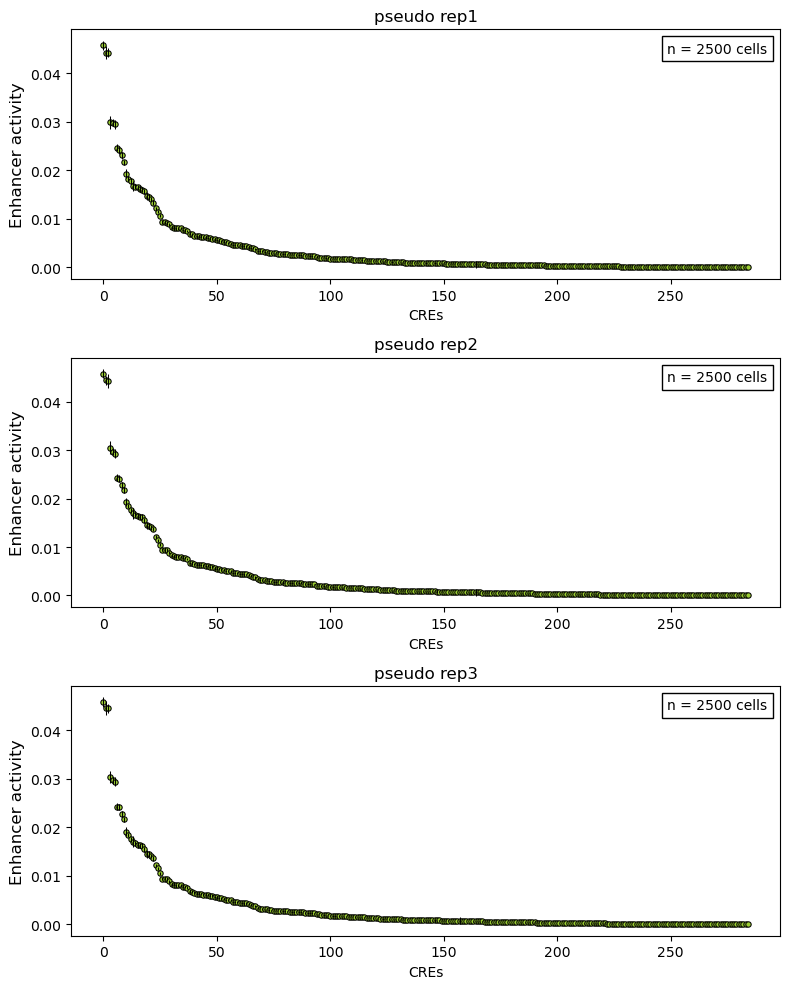

In [218]:
# Plot the enhancer activity scores in a descending order

fig, axs = plt.subplots(3, 1, figsize=(8,10))

axs[0].scatter(range(0,20), dp_sorted1['score'], marker='o', c='yellowgreen', edgecolor='k', s=15, lw=0.75)
axs[0].errorbar(range(0,20), dp_sorted1['score'], dp_sorted1['stderr'], linestyle='', linewidth=0.75, capsize=None, mew=1, ecolor='k')
axs[0].set_ylabel('Enhancer activity', fontsize=12)
axs[0].set_title('pseudo rep1')
axs[0].set_xlabel('CREs')

axs[1].scatter(range(0,20), dp_sorted2['score'], marker='o', c='yellowgreen', edgecolor='k', s=15, lw=0.75)
axs[1].errorbar(range(0,20), dp_sorted2['score'], dp_sorted2['stderr'], linestyle='', linewidth=0.75, capsize=None, mew=1, ecolor='k')
axs[1].set_ylabel('Enhancer activity', fontsize=12)
axs[1].set_title('pseudo rep2')
axs[1].set_xlabel('CREs')

axs[2].scatter(range(0,20), dp_sorted3['score'], marker='o', c='yellowgreen', edgecolor='k', s=15, lw=0.75)
axs[2].errorbar(range(0,20), dp_sorted3['score'], dp_sorted3['stderr'], linestyle='', linewidth=0.75, capsize=None, mew=1, ecolor='k')
axs[2].set_ylabel('Enhancer activity', fontsize=12)
axs[2].set_title('pseudo rep3')
axs[2].set_xlabel('CREs')

# plt.xticks(np.arange(24), d2_rep2['id'], rotation=90);

numcells1 = len(pseudo_rep1)
numcells2 = len(pseudo_rep2)
numcells3 = len(pseudo_rep3)

anchored_text1 = AnchoredText(f"n = {numcells1} cells", loc=1)
axs[0].add_artist(anchored_text1)
anchored_text2 = AnchoredText(f"n = {numcells2} cells", loc=1)
axs[1].add_artist(anchored_text2)
anchored_text3 = AnchoredText(f"n = {numcells3} cells", loc=1)
axs[2].add_artist(anchored_text3)

plt.tight_layout()
# plt.savefig('/tscc/projects/ps-renlab2/zgibbs/STARR-FISH/300CRE_HCT116_analysis/figures/psuedo_reps_from_rep1', dpi=600)
plt.show()

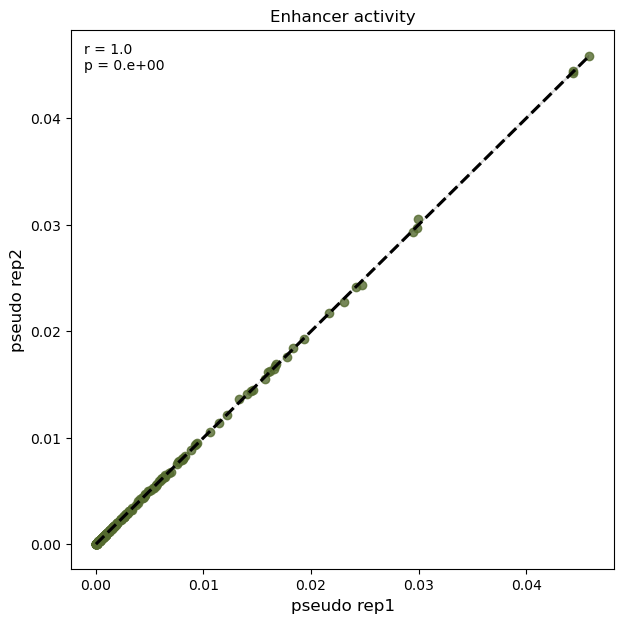

In [220]:
# plot the correlation between pseudo replicates

import seaborn as sns
from scipy import stats

fig, ax = plt.subplots(figsize=(7,7))

x = dp_sorted1['score']
y = dp_sorted2['score']

# sns.set_palette("viridis")

sns.regplot(x=x, y=y,
            color='darkolivegreen',
            line_kws={'ls' : 'dashed', 'color' : 'k'})

ax.set_ylabel('pseudo rep2', fontsize=12)
ax.set_xlabel('pseudo rep1', fontsize=12)
ax.set_title('Enhancer activity')

stats = stats.pearsonr(x, y)

corrcoef = np.around(stats[0], 2)
pval = np.format_float_scientific(stats[1], 2)

anchored_text = AnchoredText(f"r = {corrcoef}\np = {pval}", loc=2, frameon=False)
ax.add_artist(anchored_text)

# plt.savefig('/projects/ps-renlab2/zgibbs/STARR-FISH/10_12_2023__CRE-20_RNASEQ/figures/activity_score_corr_pseudo_reps2_3_230129.png', dpi=600)
plt.show()

### Try sampling smaller number of cells for linear regression: how many cells needed to measure enhancer activity?

In [19]:
df100

,0,1,2,3,4,5,6,7,8,9,stdev,avg,CV
CRE015,0.002665,0.002820,0.002628,0.003168,0.005168,0.005335,0.002224,0.002880,0.004714,0.003513,0.001138,0.003511,0.324210
CRE018,0.009768,0.010057,0.011051,0.008387,0.008486,0.008056,0.008778,0.008139,0.010508,0.009615,0.001058,0.009285,0.113969
CRE021,0.000084,0.000152,0.000151,0.000082,0.000070,0.000110,0.000058,0.000085,0.000028,0.000042,0.000042,0.000086,0.482207
CRE024,0.000407,0.000756,0.000494,0.000586,0.000707,0.000769,0.000849,0.000611,0.000483,0.000680,0.000143,0.000634,0.225332
CRE027,0.001674,0.001425,0.001573,0.001307,0.001190,0.000887,0.001684,0.002239,0.001412,0.001428,0.000356,0.001482,0.240122
...,...,...,...,...,...,...,...,...,...,...,...,...,...
CRE287,0.000041,0.000015,0.000016,0.000053,0.000286,0.000033,-0.000015,0.000038,0.000153,0.000024,0.000089,0.000064,1.394299
CRE290,0.000078,0.000183,0.000234,0.000250,0.000114,0.000139,0.000200,0.000223,0.000131,0.000156,0.000056,0.000171,0.330293
CRE293,0.000031,0.000068,0.000074,0.000076,0.000043,0.000021,0.000031,0.000027,0.000026,0.000024,0.000022,0.000042,0.516935
CRE296,0.020462,0.014629,0.015231,0.015666,0.015416,0.015718,0.020682,0.016609,0.014787,0.013927,0.002357,0.016313,0.144482


In [27]:
from scipy import stats

# set number of sampled dataframes to create
num_samples = 10

# generate empty list for appending new sampled dataframes
sampled_dfs = []

# repeatedly sample the dataframe for slopes and append to the list
for _ in range(num_samples):
    pseudo_rep = all_cbg_rep1.sample(n=100)

    pseudo_res = []

    for cre in pseudo_rep.columns[1:21]:
        res = stats.linregress(pseudo_rep['total transcripts'], pseudo_rep[cre])
        pseudo_res.append(res)
        
    y = [pseudo_res[i].slope for i in range(20)]
    d = pd.DataFrame(list(zip(y)), columns = ['score'], index=pseudo_rep.columns[1:21])
    sampled_dfs.append(d)

# combine sampled data into one new dataframe and calculate standard deviation across samplings
df100 = pd.concat(sampled_dfs, ignore_index=True, axis=1)
df100['stdev'] = df100.std(axis=1)
df100['avg'] = df100[df100.columns[:10]].mean(axis=1)
df100['CV'] = df100.stdev/df100.avg
d100 = df100.sort_values('avg', axis=0, ascending=False)

In [28]:
from scipy import stats

# set number of sampled dataframes to create
num_samples = 10

# generate empty list for appending new sampled dataframes
sampled_dfs = []

# repeatedly sample the dataframe for slopes and append to the list
for _ in range(num_samples):
    pseudo_rep = all_cbg_rep1.sample(n=50)

    pseudo_res = []

    for cre in pseudo_rep.columns[1:21]:
        res = stats.linregress(pseudo_rep['total transcripts'], pseudo_rep[cre])
        pseudo_res.append(res)
        
    y = [pseudo_res[i].slope for i in range(20)]
    d = pd.DataFrame(list(zip(y)), columns = ['score'], index=pseudo_rep.columns[1:21])
    sampled_dfs.append(d)

# combine sampled data into one new dataframe and calculate standard deviation across samplings
df50 = pd.concat(sampled_dfs, ignore_index=True, axis=1)
df50['stdev'] = df50.std(axis=1)
df50['avg'] = df50[df50.columns[:10]].mean(axis=1)
df50['CV'] = df50.stdev/df50.avg
d50 = df50.sort_values('avg', axis=0, ascending=False)

In [29]:
from scipy import stats

# set number of sampled dataframes to create
num_samples = 10

# generate empty list for appending new sampled dataframes
sampled_dfs = []

# repeatedly sample the dataframe for slopes and append to the list
for _ in range(num_samples):
    pseudo_rep = all_cbg_rep1.sample(n=250)

    pseudo_res = []

    for cre in pseudo_rep.columns[1:21]:
        res = stats.linregress(pseudo_rep['total transcripts'], pseudo_rep[cre])
        pseudo_res.append(res)
        
    y = [pseudo_res[i].slope for i in range(20)]
    d = pd.DataFrame(list(zip(y)), columns = ['score'], index=pseudo_rep.columns[1:21])
    sampled_dfs.append(d)

# combine sampled data into one new dataframe and calculate standard deviation across samplings
df250 = pd.concat(sampled_dfs, ignore_index=True, axis=1)
df250['stdev'] = df250.std(axis=1)
df250['avg'] = df250[df250.columns[:10]].mean(axis=1)
df250['CV'] = df250.stdev/df250.avg
d250 = df250.sort_values('avg', axis=0, ascending=False)

In [30]:
from scipy import stats

# set number of sampled dataframes to create
num_samples = 10

# generate empty list for appending new sampled dataframes
sampled_dfs = []

# repeatedly sample the dataframe for slopes and append to the list
for _ in range(num_samples):
    pseudo_rep = all_cbg_rep1.sample(n=500)

    pseudo_res = []

    for cre in pseudo_rep.columns[1:21]:
        res = stats.linregress(pseudo_rep['total transcripts'], pseudo_rep[cre])
        pseudo_res.append(res)
        
    y = [pseudo_res[i].slope for i in range(20)]
    d = pd.DataFrame(list(zip(y)), columns = ['score'], index=pseudo_rep.columns[1:21])
    sampled_dfs.append(d)

# combine sampled data into one new dataframe and calculate standard deviation across samplings
df500 = pd.concat(sampled_dfs, ignore_index=True, axis=1)
df500['stdev'] = df500.std(axis=1)
df500['avg'] = df500[df500.columns[:10]].mean(axis=1)
df500['CV'] = df500.stdev/df500.avg
d500 = df500.sort_values('avg', axis=0, ascending=False)

In [31]:
from scipy import stats

# set number of sampled dataframes to create
num_samples = 10

# generate empty list for appending new sampled dataframes
sampled_dfs = []

# repeatedly sample the dataframe for slopes and append to the list
for _ in range(num_samples):
    pseudo_rep = all_cbg_rep1.sample(n=1000)

    pseudo_res = []

    for cre in pseudo_rep.columns[1:21]:
        res = stats.linregress(pseudo_rep['total transcripts'], pseudo_rep[cre])
        pseudo_res.append(res)
        
    y = [pseudo_res[i].slope for i in range(20)]
    d = pd.DataFrame(list(zip(y)), columns = ['score'], index=pseudo_rep.columns[1:21])
    sampled_dfs.append(d)

# combine sampled data into one new dataframe and calculate standard deviation across samplings
df1000 = pd.concat(sampled_dfs, ignore_index=True, axis=1)
df1000['stdev'] = df1000.std(axis=1)
df1000['avg'] = df1000[df1000.columns[:10]].mean(axis=1)
df1000['CV'] = df1000.stdev/df1000.avg
d1000 = df1000.sort_values('avg', axis=0, ascending=False)

In [32]:
from scipy import stats

# set number of sampled dataframes to create
num_samples = 10

# generate empty list for appending new sampled dataframes
sampled_dfs = []

# repeatedly sample the dataframe for slopes and append to the list
for _ in range(num_samples):
    pseudo_rep = all_cbg_rep1.sample(n=2500)

    pseudo_res = []

    for cre in pseudo_rep.columns[1:21]:
        res = stats.linregress(pseudo_rep['total transcripts'], pseudo_rep[cre])
        pseudo_res.append(res)
        
    y = [pseudo_res[i].slope for i in range(20)]
    d = pd.DataFrame(list(zip(y)), columns = ['score'], index=pseudo_rep.columns[1:21])
    sampled_dfs.append(d)

# combine sampled data into one new dataframe and calculate standard deviation across samplings
df2500 = pd.concat(sampled_dfs, ignore_index=True, axis=1)
df2500['stdev'] = df2500.std(axis=1)
df2500['avg'] = df2500[df2500.columns[:10]].mean(axis=1)
df2500['CV'] = df2500.stdev/df2500.avg
d2500 = df2500.sort_values('avg', axis=0, ascending=False)

In [33]:
colors = {'CRE001' : '#f77189',
        'CRE002' : '#f7755d',
        'CRE003' : '#e68332',
        'CRE004' : '#ce9032',
        'CRE005' : '#bb9832',
        'CRE006' : '#aa9e31',
        'CRE007' : '#97a431',
        'CRE008' : '#7eaa31',
        'CRE009' : '#50b131',
        'CRE010' : '#32b166',
        'CRE011' : '#34af84',
        'CRE012' : '#35ae96',
        'CRE013' : '#36ada4',
        'CRE014' : '#37abb1',
        'CRE015' : '#38aabf',
        'CRE016' : '#39a7d0',
        'CRE017' : '#3ba3ec',
        'CRE018' : '#7a98f4',
        'CRE019' : '#a48cf4',
        'CRE020' : '#c67df4',
        'blank1' : '#e866f4',
        'blank2' : '#f561dd',
        'blank3' : '#f668c2',
        'blank4' : '#f66ca8'}

CREs = ['CRE001', 'CRE002', 'CRE003', 'CRE004', 'CRE005', 'CRE006', 'CRE007', 'CRE008',
        'CRE009', 'CRE010', 'CRE011', 'CRE012', 'CRE013', 'CRE014', 'CRE015', 'CRE016',
        'CRE017', 'CRE018', 'CRE019', 'CRE020', 'blank1', 'blank2', 'blank3', 'blank4']

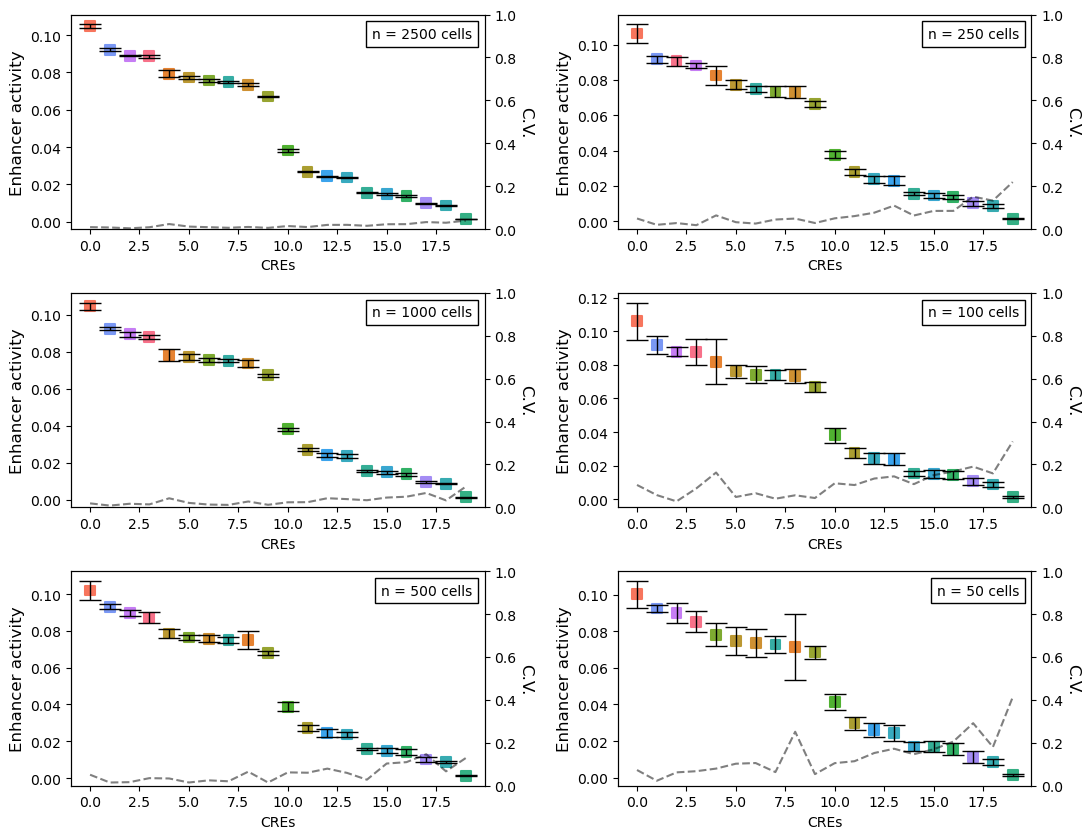

In [39]:
# Plot the enhancer activity scores in a descending order

import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText

fig, axs = plt.subplots(3, 2, figsize=(11,8.5))

axs[0,0].scatter(range(0,20), d2500['avg'], marker='s', c=[colors[i] for i in d2500.index], s=50, lw=1.5)
axs[0,0].errorbar(range(0,20), d2500['avg'], d2500['stdev'], linestyle='', linewidth=1, capsize=8, mew=1, ecolor='k')
axs[0,0].set_ylabel('Enhancer activity', fontsize=12)
axs[0,0].set_xlabel('CREs')
# axs[0,0].set_title('2500 cells')

ax1 = axs[0, 0].twinx()
ax1.plot(range(0,20), d2500['CV'], lw=1.5, c='k', linestyle='--', alpha=0.5, zorder=1)
ax1.set_ylim(0,1)
ax1.set_ylabel('C.V.', fontsize=12, rotation=270, labelpad=12)

axs[1,0].scatter(range(0,20), d1000['avg'], marker='s', c=[colors[i] for i in d1000.index], s=50, lw=1.5)
axs[1,0].errorbar(range(0,20), d1000['avg'], d1000['stdev'], linestyle='', linewidth=1, capsize=8, mew=1, ecolor='k')
axs[1,0].set_ylabel('Enhancer activity', fontsize=12)
axs[1,0].set_xlabel('CREs')
# axs[1,0].set_title('1000 cells')

ax2 = axs[1, 0].twinx()
ax2.plot(range(0,20), d1000['CV'], lw=1.5, c='k', linestyle='--', alpha=0.5, zorder=1)
ax2.set_ylim(0,1)
ax2.set_ylabel('C.V.', fontsize=12, rotation=270, labelpad=12)

axs[2,0].scatter(range(0,20), d500['avg'], marker='s', c=[colors[i] for i in d500.index], s=50, lw=1.5)
axs[2,0].errorbar(range(0,20), d500['avg'], d500['stdev'], linestyle='', linewidth=1, capsize=8, mew=1, ecolor='k')
axs[2,0].set_ylabel('Enhancer activity', fontsize=12)
axs[2,0].set_xlabel('CREs')
# axs[2,0].set_title('500 cells')

ax3 = axs[2, 0].twinx()
ax3.plot(range(0,20), d500['CV'], lw=1.5, c='k', linestyle='--', alpha=0.5, zorder=1)
ax3.set_ylim(0,1)
ax3.set_ylabel('C.V.', fontsize=12, rotation=270, labelpad=12)

axs[0,1].scatter(range(0,20), d250['avg'], marker='s', c=[colors[i] for i in d250.index], s=50, lw=1.5)
axs[0,1].errorbar(range(0,20), d250['avg'], d250['stdev'], linestyle='', linewidth=1, capsize=8, mew=1, ecolor='k')
axs[0,1].set_ylabel('Enhancer activity', fontsize=12)
axs[0,1].set_xlabel('CREs')
# axs[0,1].set_title('250 cells')

ax4 = axs[0, 1].twinx()
ax4.plot(range(0,20), d250['CV'], lw=1.5, c='k', linestyle='--', alpha=0.5, zorder=1)
ax4.set_ylim(0,1)
ax4.set_ylabel('C.V.', fontsize=12, rotation=270, labelpad=12)

axs[1,1].scatter(range(0,20), d100['avg'], marker='s', c=[colors[i] for i in d100.index], s=50, lw=1.5)
axs[1,1].errorbar(range(0,20), d100['avg'], d100['stdev'], linestyle='', linewidth=1, capsize=8, mew=1, ecolor='k')
axs[1,1].set_ylabel('Enhancer activity', fontsize=12)
axs[1,1].set_xlabel('CREs')
# axs[1,1].set_title('100 cells')

ax5 = axs[1, 1].twinx()
ax5.plot(range(0,20), d100['CV'], lw=1.5, c='k', linestyle='--', alpha=0.5, zorder=1)
ax5.set_ylim(0,1)
ax5.set_ylabel('C.V.', fontsize=12, rotation=270, labelpad=12)

axs[2,1].scatter(range(0,20), d50['avg'], marker='s', c=[colors[i] for i in d50.index], s=50, lw=1.5)
axs[2,1].errorbar(range(0,20), d50['avg'], d50['stdev'], linestyle='', linewidth=1, capsize=8, mew=1, ecolor='k')
axs[2,1].set_ylabel('Enhancer activity', fontsize=12)
axs[2,1].set_xlabel('CREs')
# axs[2,1].set_title('50 cells')

ax6 = axs[2, 1].twinx()
ax6.plot(range(0,20), d50['CV'], lw=1.5, c='k', linestyle='--', alpha=0.5, zorder=1)
ax6.set_ylim(0,1)
ax6.set_ylabel('C.V.', fontsize=12, rotation=270, labelpad=12)

anchored_text1 = AnchoredText(f"n = 2500 cells", loc=1)
axs[0,0].add_artist(anchored_text1)
anchored_text2 = AnchoredText(f"n = 1000 cells", loc=1)
axs[1,0].add_artist(anchored_text2)
anchored_text3 = AnchoredText(f"n = 500 cells", loc=1)
axs[2,0].add_artist(anchored_text3)

anchored_text4 = AnchoredText(f"n = 250 cells", loc=1)
axs[0,1].add_artist(anchored_text4)
anchored_text5 = AnchoredText(f"n = 100 cells", loc=1)
axs[1,1].add_artist(anchored_text5)
anchored_text6 = AnchoredText(f"n = 50 cells", loc=1)
axs[2,1].add_artist(anchored_text6)

plt.tight_layout()
# plt.savefig('/home/zgibbs/STARR-FISH/HCT116_20CRE_analysis/figures/activity_score_downsampled_with_CV_total_transcript_normalized_240607.pdf')
plt.show()

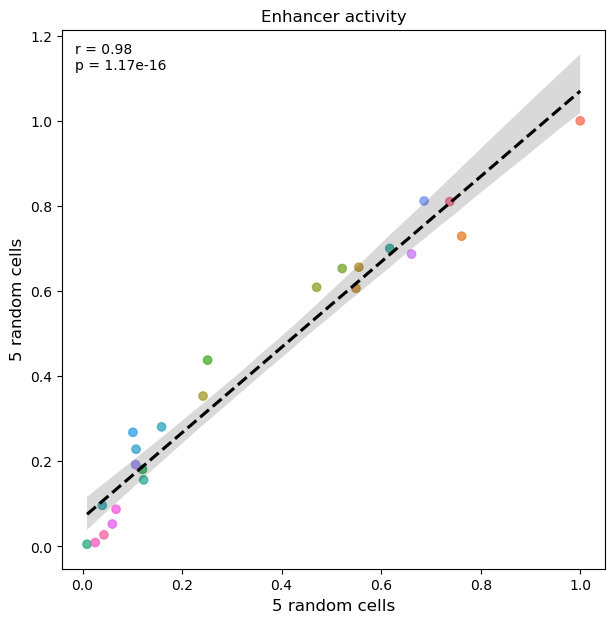

In [118]:
# plot correlation between full dataset and downsampled datasets

from matplotlib.offsetbox import AnchoredText
from scipy import stats
import seaborn as sns

fig, ax = plt.subplots(figsize=(7,7))

x = df10['avg']
y = df500['avg']

# sns.set_palette("viridis")

sns.regplot(x=x, y=y,
            color='darkolivegreen',
            line_kws={'ls' : 'dashed', 'color' : 'k'},
            scatter_kws={'color' : [colors[i] for i in d_full['id']]})

ax.set_ylabel('5 random cells', fontsize=12)
ax.set_xlabel('5 random cells', fontsize=12)
ax.set_title('Enhancer activity')

stats = stats.pearsonr(x, y)

corrcoef = np.around(stats[0], 2)
pval = np.format_float_scientific(stats[1], 2)

anchored_text = AnchoredText(f"r = {corrcoef}\np = {pval}", loc=2, frameon=False)
ax.add_artist(anchored_text)

# plt.tight_layout()
# plt.savefig('/projects/ps-renlab2/zgibbs/STARR-FISH/10_12_2023__CRE-20_RNASEQ/figures/activity_score_corr_10_vs_10_cells_240130.png', dpi=600)
plt.show()